# Laboratorio 1 - Clasificacion con Perceptron Multicapa (MLP)
**Claudia Pereira Cuba**  
**Materia: SIs421**

---

En este laboratorio se construye un modelo de clasificacion basado en el Perceptron Multicapa (MLP) usando PyTorch. Se aplican tecnicas de optimizacion, regularizacion y buenas practicas de entrenamiento. El objetivo es mostrar todo el flujo de trabajo: desde el analisis exploratorio del dataset hasta la evaluacion y prueba del modelo final.

## 1. Instalacion e importacion de librerias

Antes de comenzar, importamos todas las librerias que vamos a necesitar. Usaremos PyTorch para construir y entrenar la red neuronal, scikit-learn para preparar los datos y calcular metricas, y matplotlib junto con seaborn para visualizar los resultados.

In [ ]:
# Instalamos las librerias necesarias en caso de que no esten disponibles
!pip install torch torchvision scikit-learn matplotlib seaborn pandas numpy --quiet

In [ ]:
# Importamos todas las librerias del proyecto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch para construir la red neuronal
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn para datos y metricas
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)

# Semilla para reproducibilidad de resultados
torch.manual_seed(42)
np.random.seed(42)

print("Librerias cargadas correctamente.")
print(f"Version de PyTorch: {torch.__version__}")

Librerias cargadas correctamente.
Version de PyTorch: 2.11.0+cpu


## 2. Conociendo el dataset: Wine

El dataset que vamos a utilizar es el conocido **Wine Dataset** de UCI / scikit-learn. Contiene datos quimicos de vinos producidos en Italia, provenientes de tres cultivares distintos. Cada muestra tiene 13 caracteristicas numericas (como el contenido de alcohol, la acidez, el color, etc.) y pertenece a una de tres clases: cultivar 0, 1 o 2.

Es un dataset para entrenar una red neuronal. La tarea consiste en clasificar un vino en su cultivar correcto a partir de sus propiedades quimicas.

In [ ]:
# Cargamos el dataset directamente desde scikit-learn
wine = load_wine()

# Convertimos a DataFrame para facilitar la exploracion
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['cultivar'] = df['target'].map({0: 'Cultivar 0', 1: 'Cultivar 1', 2: 'Cultivar 2'})

print("Forma del dataset:", df.shape)
print("\nClases:", wine.target_names)
print("\nDistribucion de clases:")
print(df['cultivar'].value_counts())

Forma del dataset: (178, 15)

Clases: ['class_0' 'class_1' 'class_2']

Distribucion de clases:
cultivar
Cultivar 1    71
Cultivar 0    59
Cultivar 2    48
Name: count, dtype: int64


In [ ]:
# Vemos las primeras filas del dataset
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cultivar 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cultivar 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cultivar 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cultivar 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cultivar 0


In [ ]:
# Estadisticas descriptivas del dataset
df.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


## 3. Analisis exploratorio de los datos

Antes de entrenar cualquier modelo es fundamental entender los datos. Vamos a explorar la distribucion de las clases, las correlaciones entre variables y como se relacionan algunas caracteristicas con el cultivar al que pertenecen. Esto nos ayuda a tener una idea de la complejidad del problema.

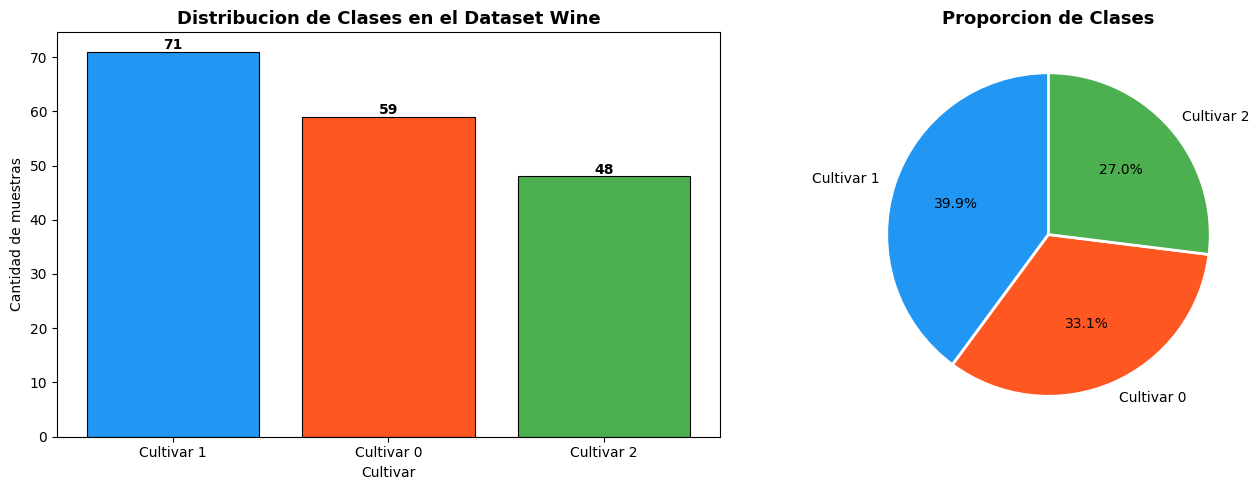

In [ ]:
# Grafico 1: Distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras
colores = ['#2196F3', '#FF5722', '#4CAF50']
conteo = df['cultivar'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=colores, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribucion de Clases en el Dataset Wine', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cultivar')
axes[0].set_ylabel('Cantidad de muestras')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Grafico de torta
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=colores, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporcion de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

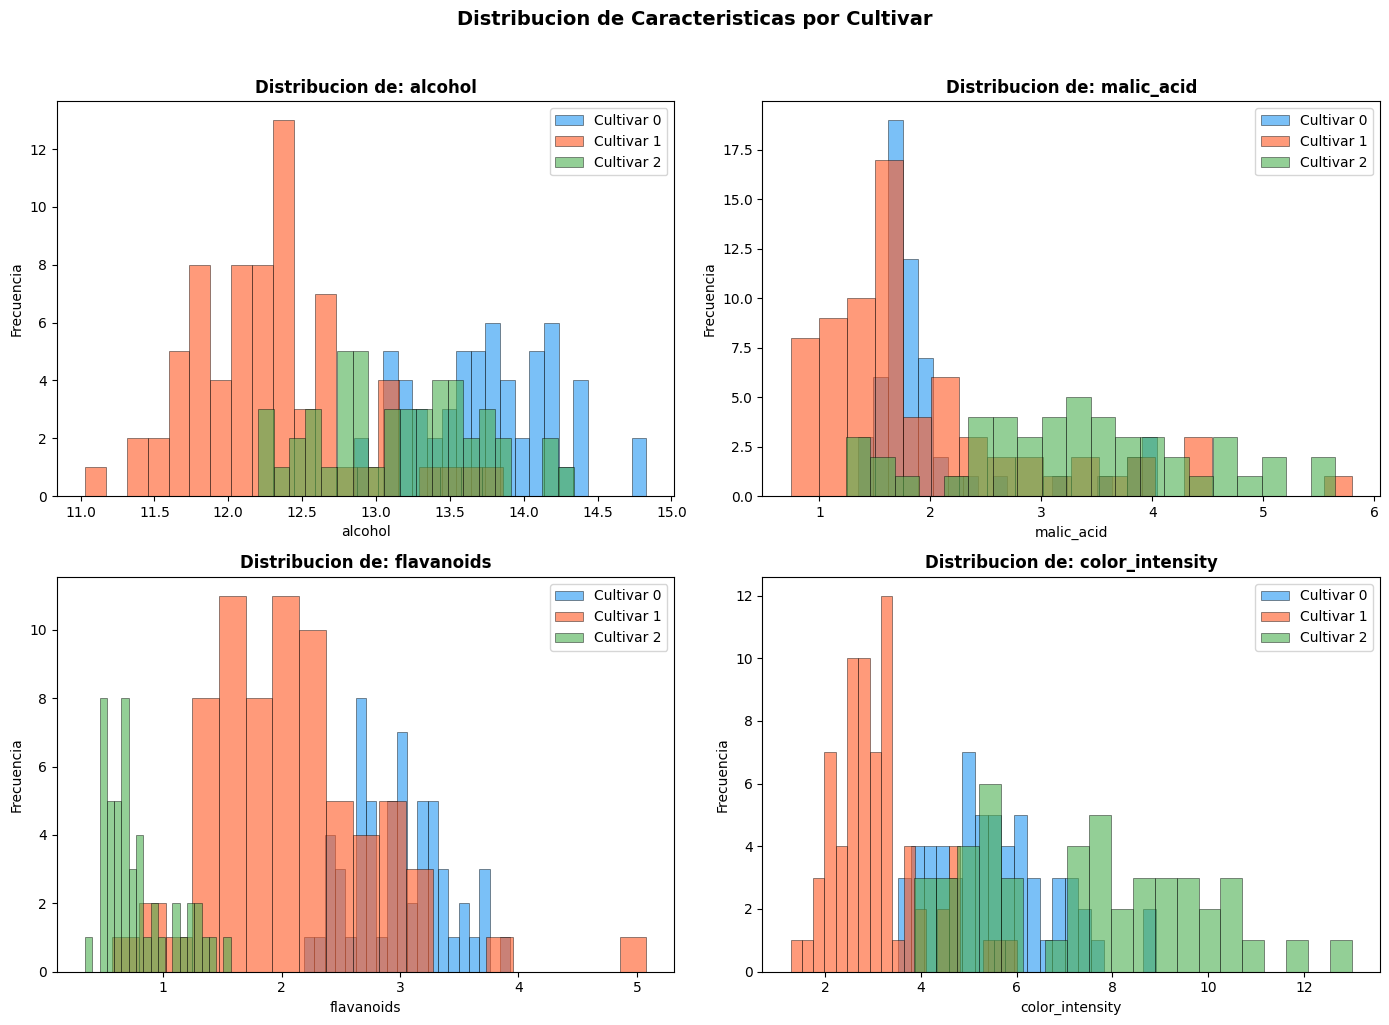

In [ ]:
# Grafico 2: Distribucion de algunas caracteristicas por clase
# Elegimos 4 de las variables mas representativas para visualizar
features_a_graficar = ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features_a_graficar):
    for j, (nombre_clase, color) in enumerate(zip(['Cultivar 0', 'Cultivar 1', 'Cultivar 2'], colores)):
        datos = df[df['cultivar'] == nombre_clase][feat]
        axes[i].hist(datos, bins=20, alpha=0.6, color=color, label=nombre_clase, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Distribucion de: {feat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Distribucion de Caracteristicas por Cultivar', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

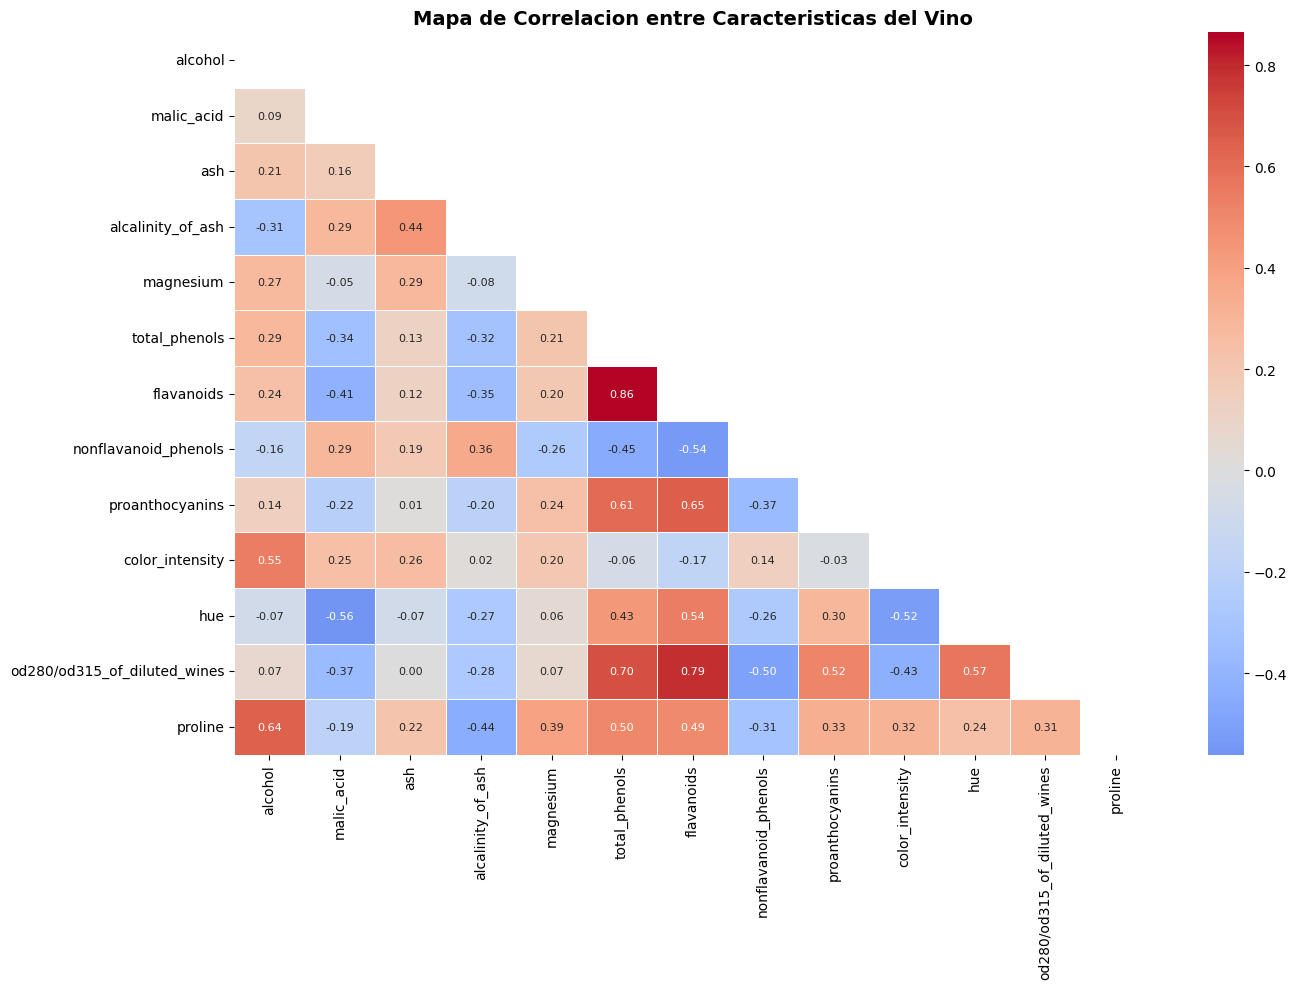

In [ ]:
# Grafico 3: Mapa de calor de correlaciones entre variables
plt.figure(figsize=(14, 10))
correlacion = df[wine.feature_names].corr()
mascara = np.triu(np.ones_like(correlacion, dtype=bool))  # mostramos solo la mitad inferior

sns.heatmap(
    correlacion,
    mask=mascara,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Mapa de Correlacion entre Caracteristicas del Vino', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3166/3711193366.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cultivar', y='alcohol', palette=colores, ax=axes[0])
/tmp/ipykernel_3166/3711193366.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cultivar', y='flavanoids', palette=colores, ax=axes[1])


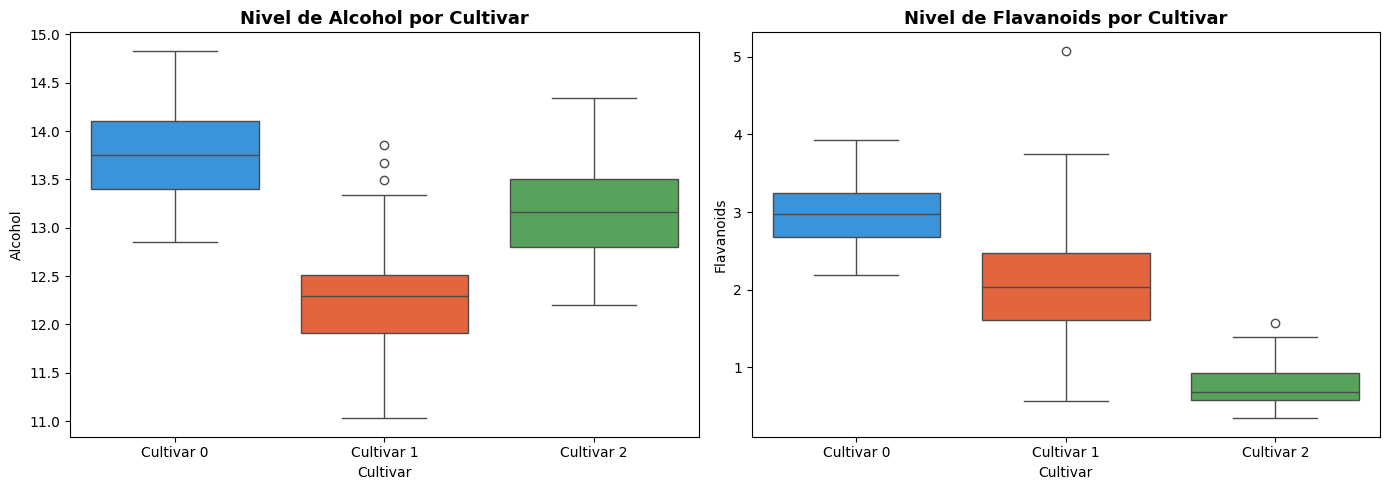

In [ ]:
# Grafico 4: Boxplot de alcohol y flavanoids por cultivar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='cultivar', y='alcohol', palette=colores, ax=axes[0])
axes[0].set_title('Nivel de Alcohol por Cultivar', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cultivar')
axes[0].set_ylabel('Alcohol')

sns.boxplot(data=df, x='cultivar', y='flavanoids', palette=colores, ax=axes[1])
axes[1].set_title('Nivel de Flavanoids por Cultivar', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cultivar')
axes[1].set_ylabel('Flavanoids')

plt.tight_layout()
plt.show()

## 4. Preparacion de los datos

Para entrenar la red neuronal necesitamos preparar los datos correctamente. Primero dividimos el dataset en conjunto de entrenamiento, validacion y prueba. Luego aplicamos normalizacion (StandardScaler) para que todas las variables tengan la misma escala, lo cual es una buena practica fundamental cuando se trabaja con redes neuronales. Finalmente convertimos los datos a tensores de PyTorch.

In [ ]:
# Separamos las caracteristicas (X) y las etiquetas (y)
X = wine.data.astype(np.float32)
y = wine.target

# Division: 70% entrenamiento, 15% validacion, 15% prueba
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Conjunto de entrenamiento : {X_train.shape[0]} muestras")
print(f"Conjunto de validacion    : {X_val.shape[0]} muestras")
print(f"Conjunto de prueba        : {X_test.shape[0]} muestras")

# Normalizacion: ajustamos SOLO con los datos de entrenamiento
# para evitar fuga de informacion (data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# Convertimos a tensores de PyTorch
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Creamos DataLoaders para iterar en mini-batches durante el entrenamiento
BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE)

print("\nDatos preparados y listos para el entrenamiento.")

Conjunto de entrenamiento : 124 muestras
Conjunto de validacion    : 27 muestras
Conjunto de prueba        : 27 muestras

Datos preparados y listos para el entrenamiento.


## 5. Definicion del modelo MLP

Vamos a definir nuestra red neuronal MLP usando PyTorch. La arquitectura que elegimos tiene:
- Una capa de entrada con 13 neuronas (una por cada caracteristica del vino)
- Dos capas ocultas con 64 y 32 neuronas respectivamente, con activacion ReLU
- Dropout en las capas ocultas como tecnica de regularizacion para evitar el sobreajuste
- Batch Normalization para estabilizar el entrenamiento
- Una capa de salida con 3 neuronas (una por cada cultivar)

Para la optimizacion usaremos Adam, que es uno de los optimizadores mas robustos en la practica, combinado con un scheduler de tasa de aprendizaje que reduce el learning rate cuando la perdida deja de mejorar.

In [ ]:
class MLP_Vino(nn.Module):
    """
    Red Neuronal MLP para clasificacion de vinos.
    Arquitectura: 13 -> 64 -> 32 -> 3
    Regularizacion: Dropout + Batch Normalization
    """
    def __init__(self, n_entradas=13, n_clases=3, dropout_p=0.3):
        super(MLP_Vino, self).__init__()

        self.red = nn.Sequential(
            # Capa oculta 1: 13 entradas -> 64 neuronas
            nn.Linear(n_entradas, 64),
            nn.BatchNorm1d(64),      # Normalizacion por lote: estabiliza el gradiente
            nn.ReLU(),               # Activacion no lineal
            nn.Dropout(dropout_p),   # Dropout: apaga neuronas al azar para regularizar

            # Capa oculta 2: 64 -> 32 neuronas
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            # Capa de salida: 32 -> 3 clases
            nn.Linear(32, n_clases)
            # No aplicamos Softmax aqui porque CrossEntropyLoss ya lo incluye internamente
        )

        # Inicializacion de pesos con He (recomendada para ReLU)
        self._inicializar_pesos()

    def _inicializar_pesos(self):
        # Recorremos cada capa y aplicamos inicializacion de Kaiming para capas lineales
        for capa in self.red:
            if isinstance(capa, nn.Linear):
                nn.init.kaiming_normal_(capa.weight, nonlinearity='relu')
                nn.init.zeros_(capa.bias)

    def forward(self, x):
        # Pasada hacia adelante: la entrada pasa por toda la red
        return self.red(x)


# Creamos el modelo
modelo = MLP_Vino(n_entradas=13, n_clases=3, dropout_p=0.3)
print(modelo)
print(f"\nTotal de parametros entrenables: {sum(p.numel() for p in modelo.parameters() if p.requires_grad):,}")

MLP_Vino(
  (red): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
)

Total de parametros entrenables: 3,267


In [ ]:
# Configuramos la funcion de perdida, el optimizador y el scheduler

# CrossEntropyLoss: apropiada para clasificacion multiclase
criterio = nn.CrossEntropyLoss()

# Adam: optimizador adaptativo, muy efectivo en la practica
# weight_decay es la regularizacion L2 que penaliza pesos grandes
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# ReduceLROnPlateau: reduce el learning rate si la perdida de validacion no mejora en 10 epocas
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', patience=10, factor=0.5, verbose=False)
# ReduceLROnPlateau: reduce el learning rate si la perdida de validacion no mejora en 10 epocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', patience=10, factor=0.5)
print("Configuracion del entrenamiento lista.")

Configuracion del entrenamiento lista.


## 6. Entrenamiento del modelo

Ahora entrenamos la red durante 150 epocas. En cada epoca, el modelo aprende con los datos de entrenamiento usando mini-batches y al final de cada epoca evaluamos su rendimiento con los datos de validacion. Guardamos los pesos del mejor modelo segun la perdida de validacion, una practica conocida como Early Stopping manual.

In [ ]:
def entrenar_epoca(modelo, loader, criterio, optimizador):
    """Funcion que entrena el modelo durante una epoca completa."""
    modelo.train()  # Activamos el modo entrenamiento (habilita Dropout y BatchNorm)
    perdida_total, correctos, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        optimizador.zero_grad()              # Limpiamos gradientes del paso anterior
        salidas = modelo(X_batch)            # Pasada hacia adelante
        perdida = criterio(salidas, y_batch) # Calculamos la perdida
        perdida.backward()                   # Retropropagacion
        optimizador.step()                   # Actualizacion de pesos

        perdida_total += perdida.item() * X_batch.size(0)
        _, predicciones = torch.max(salidas, 1)
        correctos += (predicciones == y_batch).sum().item()
        total += y_batch.size(0)

    return perdida_total / total, correctos / total


def evaluar(modelo, loader, criterio):
    """Funcion que evalua el modelo en modo inferencia (sin actualizar pesos)."""
    modelo.eval()  # Desactivamos Dropout y BatchNorm usa estadisticas globales
    perdida_total, correctos, total = 0.0, 0, 0

    with torch.no_grad():  # No calculamos gradientes (mas rapido y ahorra memoria)
        for X_batch, y_batch in loader:
            salidas = modelo(X_batch)
            perdida = criterio(salidas, y_batch)
            perdida_total += perdida.item() * X_batch.size(0)
            _, predicciones = torch.max(salidas, 1)
            correctos += (predicciones == y_batch).sum().item()
            total += y_batch.size(0)

    return perdida_total / total, correctos / total


# Ciclo principal de entrenamiento
EPOCAS = 150
historial = {'perdida_train': [], 'acc_train': [], 'perdida_val': [], 'acc_val': []}
mejor_perdida_val = float('inf')
mejores_pesos = None

print(f"Iniciando entrenamiento por {EPOCAS} epocas...")
print("-" * 65)
print(f"{'Epoca':>6} | {'Loss Train':>10} | {'Acc Train':>10} | {'Loss Val':>8} | {'Acc Val':>8}")
print("-" * 65)

for epoca in range(1, EPOCAS + 1):
    loss_t, acc_t = entrenar_epoca(modelo, train_loader, criterio, optimizador)
    loss_v, acc_v = evaluar(modelo, val_loader, criterio)

    # Guardamos el historial para graficar despues
    historial['perdida_train'].append(loss_t)
    historial['acc_train'].append(acc_t)
    historial['perdida_val'].append(loss_v)
    historial['acc_val'].append(acc_v)

    # Actualizamos el learning rate basado en la perdida de validacion
    scheduler.step(loss_v)

    # Guardamos los mejores pesos del modelo (Early Stopping manual)
    if loss_v < mejor_perdida_val:
        mejor_perdida_val = loss_v
        mejores_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}

    # Mostramos el progreso cada 25 epocas
    if epoca % 25 == 0 or epoca == 1:
        print(f"{epoca:>6} | {loss_t:>10.4f} | {acc_t*100:>9.1f}% | {loss_v:>8.4f} | {acc_v*100:>7.1f}%")

print("-" * 65)
print("Entrenamiento completado. Cargando los mejores pesos guardados...")

# Restauramos los mejores pesos encontrados durante el entrenamiento
modelo.load_state_dict(mejores_pesos)
print("Modelo listo.")

Iniciando entrenamiento por 150 epocas...
-----------------------------------------------------------------
 Epoca | Loss Train |  Acc Train | Loss Val |  Acc Val
-----------------------------------------------------------------
     1 |     0.1030 |      96.0% |   0.0373 |   100.0%
    25 |     0.0393 |     100.0% |   0.0408 |   100.0%
    50 |     0.0396 |     100.0% |   0.0412 |   100.0%
    75 |     0.0455 |     100.0% |   0.0390 |   100.0%
   100 |     0.0489 |      99.2% |   0.0405 |   100.0%
   125 |     0.0690 |      98.4% |   0.0396 |   100.0%
   150 |     0.0757 |      97.6% |   0.0406 |   100.0%
-----------------------------------------------------------------
Entrenamiento completado. Cargando los mejores pesos guardados...
Modelo listo.


## 7. Analisis de resultados: Curvas de aprendizaje

Las curvas de aprendizaje nos permiten entender como evoluciono el entrenamiento. Si la perdida de entrenamiento y la de validacion bajan juntas, el modelo esta aprendiendo bien. Si la de entrenamiento baja mucho pero la de validacion se estanca o sube, hay sobreajuste (overfitting).

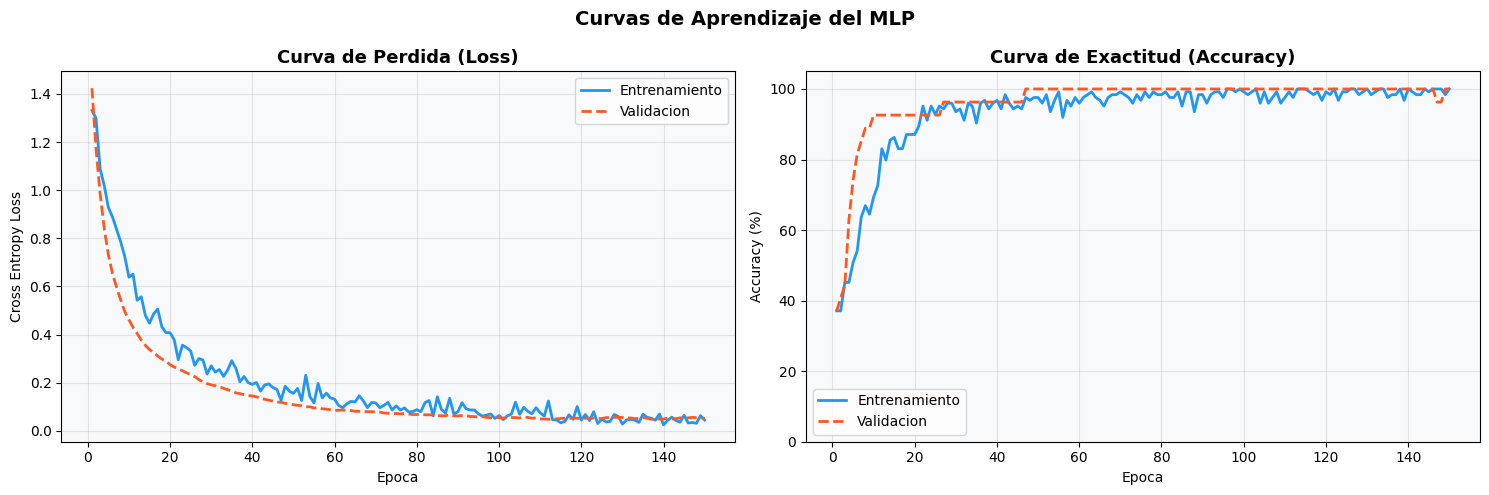

In [ ]:
# Grafico de curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epocas_eje = range(1, EPOCAS + 1)

# Curva de perdida
axes[0].plot(epocas_eje, historial['perdida_train'], label='Entrenamiento', color='#2196F3', linewidth=2)
axes[0].plot(epocas_eje, historial['perdida_val'],   label='Validacion',    color='#FF5722', linewidth=2, linestyle='--')
axes[0].set_title('Curva de Perdida (Loss)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# Curva de exactitud
axes[1].plot(epocas_eje, [a*100 for a in historial['acc_train']], label='Entrenamiento', color='#2196F3', linewidth=2)
axes[1].plot(epocas_eje, [a*100 for a in historial['acc_val']],   label='Validacion',    color='#FF5722', linewidth=2, linestyle='--')
axes[1].set_title('Curva de Exactitud (Accuracy)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f8f9fa')
axes[1].set_ylim([0, 105])

plt.suptitle('Curvas de Aprendizaje del MLP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Evaluacion final sobre el conjunto de prueba

Una vez que el entrenamiento ha terminado y tenemos el mejor modelo guardado, lo evaluamos sobre el conjunto de prueba. Este conjunto nunca fue visto por el modelo durante el entrenamiento ni el ajuste de hiperparametros, por lo que nos da una estimacion realista del rendimiento en produccion.

In [ ]:
# Evaluacion final sobre el conjunto de prueba
modelo.eval()

with torch.no_grad():
    logits = modelo(X_test_t)
    _, y_pred_t = torch.max(logits, 1)

y_pred = y_pred_t.numpy()
y_real = y_test

acc_test = accuracy_score(y_real, y_pred)
print(f"Exactitud en el conjunto de prueba: {acc_test * 100:.2f}%")
print("\nReporte de Clasificacion:")
print(classification_report(y_real, y_pred, target_names=wine.target_names))

Exactitud en el conjunto de prueba: 37.04%

Reporte de Clasificacion:
              precision    recall  f1-score   support

     class_0       0.00      0.00      0.00         9
     class_1       0.40      0.91      0.56        11
     class_2       0.00      0.00      0.00         7

    accuracy                           0.37        27
   macro avg       0.13      0.30      0.19        27
weighted avg       0.16      0.37      0.23        27



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 9. Matriz de confusion

La matriz de confusion es una de las herramientas mas informativas para evaluar un modelo de clasificacion. Nos muestra, para cada clase real, cuantas veces el modelo predijo correctamente y cuantas veces se confundio con otra clase. La diagonal principal son los aciertos; todo lo que esta fuera de la diagonal son errores.

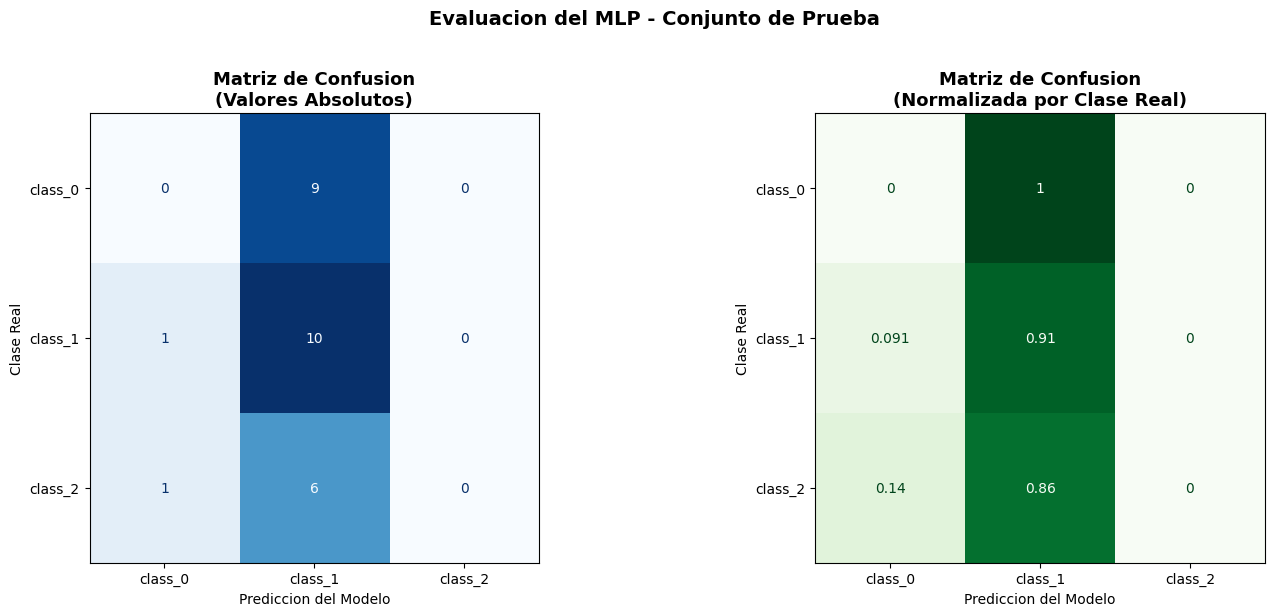


Aciertos por clase:
  class_0: 0 de 9 correctos (0.0%)
  class_1: 10 de 11 correctos (90.9%)
  class_2: 0 de 7 correctos (0.0%)


In [ ]:
# Calculamos la matriz de confusion
cm = confusion_matrix(y_real, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matriz de confusion con valores absolutos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusion\n(Valores Absolutos)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediccion del Modelo')
axes[0].set_ylabel('Clase Real')

# Matriz de confusion normalizada (porcentajes)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=wine.target_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de Confusion\n(Normalizada por Clase Real)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediccion del Modelo')
axes[1].set_ylabel('Clase Real')

plt.suptitle('Evaluacion del MLP - Conjunto de Prueba', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nAciertos por clase:")
for i, nombre in enumerate(wine.target_names):
    print(f"  {nombre}: {cm[i,i]} de {cm[i].sum()} correctos ({cm_norm[i,i]*100:.1f}%)")

## 10. Visualizacion de metricas por clase

Para tener una vision mas clara del desempeno del modelo en cada clase, graficamos las metricas de precision, recall y F1-score de forma separada. Esto es especialmente util cuando las clases no estan completamente balanceadas.

In [ ]:
# Extraemos las metricas por clase del reporte de clasificacion
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_real, y_pred, average=None)
clases = list(wine.target_names)

# Creamos un DataFrame para facilitar la visualizacion
metricas_df = pd.DataFrame({
    'Clase':     clases,
    'Precision': precision,
    'Recall':    recall,
    'F1-Score':  f1
})

# Grafico de barras agrupadas por clase
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(clases))
ancho = 0.25
barras1 = ax.bar(x - ancho, precision, ancho, label='Precision', color='#2196F3', edgecolor='black', linewidth=0.7)
barras2 = ax.bar(x,         recall,    ancho, label='Recall',    color='#FF5722', edgecolor='black', linewidth=0.7)
barras3 = ax.bar(x + ancho, f1,        ancho, label='F1-Score',  color='#4CAF50', edgecolor='black', linewidth=0.7)

# Anotamos los valores sobre cada barra
for barra in [*barras1, *barras2, *barras3]:
    h = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Cultivar', fontsize=12)
ax.set_ylabel('Valor de la Metrica', fontsize=12)
ax.set_title('Metricas de Evaluacion por Clase', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.legend()
ax.set_ylim(0, 1.15)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nResumen de metricas:")
print(metricas_df.to_string(index=False))

## 11. Prueba del modelo con nuevas muestras (Inferencia)

Una parte importante de cualquier proyecto de aprendizaje automatico es demostrar que el modelo puede hacer predicciones sobre datos que nunca ha visto. En esta seccion tomamos algunos ejemplos del conjunto de prueba y hacemos predicciones individuales, mostrando la confianza del modelo en cada clase.

In [ ]:
def predecir_muestra(modelo, x_normalizado, clase_real, nombres_clases):
    """
    Recibe una muestra ya normalizada, la pasa por el modelo y
    muestra la prediccion con las probabilidades por clase.
    """
    modelo.eval()
    with torch.no_grad():
        tensor_entrada = torch.tensor(x_normalizado, dtype=torch.float32).unsqueeze(0)
        logits = modelo(tensor_entrada)
        probabilidades = torch.softmax(logits, dim=1).squeeze().numpy()
        clase_predicha = np.argmax(probabilidades)

    correcto = "CORRECTO" if clase_predicha == clase_real else "INCORRECTO"
    print(f"  Clase real     : {nombres_clases[clase_real]}")
    print(f"  Clase predicha : {nombres_clases[clase_predicha]}  [{correcto}]")
    for i, nombre in enumerate(nombres_clases):
        barra = '#' * int(probabilidades[i] * 30)
        print(f"  {nombre:<12}: {probabilidades[i]:.4f}  {barra}")
    print()
    return clase_predicha


# Tomamos 5 muestras aleatorias del conjunto de prueba y hacemos inferencia
np.random.seed(0)
indices_muestra = np.random.choice(len(X_test), size=5, replace=False)

print("Prueba de inferencia sobre 5 muestras del conjunto de prueba")
print("=" * 55)
for i, idx in enumerate(indices_muestra):
    print(f"\nMuestra #{i+1}:")
    predecir_muestra(modelo, X_test[idx], y_test[idx], list(wine.target_names))

In [ ]:
# Grafico de barras de probabilidades para 3 muestras a la vez
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ejemplos_idx = indices_muestra[:3]

modelo.eval()
with torch.no_grad():
    for i, idx in enumerate(ejemplos_idx):
        tensor_entrada = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0)
        logits = modelo(tensor_entrada)
        probs = torch.softmax(logits, dim=1).squeeze().numpy()
        clase_pred = np.argmax(probs)
        clase_real_i = y_test[idx]

        # Color verde si acierta, rojo si falla
        colores_barra = ['#4CAF50' if j == clase_pred else '#BDBDBD' for j in range(3)]
        axes[i].bar(wine.target_names, probs, color=colores_barra, edgecolor='black', linewidth=0.7)
        for j, p in enumerate(probs):
            axes[i].text(j, p + 0.01, f'{p:.3f}', ha='center', fontsize=10, fontweight='bold')

        resultado = 'Correcto' if clase_pred == clase_real_i else 'Incorrecto'
        color_titulo = '#1B5E20' if clase_pred == clase_real_i else '#B71C1C'
        axes[i].set_title(
            f'Muestra {i+1}\nReal: {wine.target_names[clase_real_i]} | {resultado}',
            fontsize=11, fontweight='bold', color=color_titulo
        )
        axes[i].set_ylabel('Probabilidad')
        axes[i].set_ylim(0, 1.15)
        axes[i].set_facecolor('#f8f9fa')
        axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Probabilidades de Clasificacion por Muestra', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Resumen final

A lo largo de este laboratorio se construyo un Perceptron Multicapa (MLP) con PyTorch para clasificar vinos en tres cultivares distintos a partir de sus propiedades quimicas. El flujo de trabajo incluyo el analisis exploratorio del dataset, la normalizacion de datos, la definicion de una arquitectura con regularizacion mediante Dropout y Batch Normalization, el entrenamiento con el optimizador Adam y un scheduler de tasa de aprendizaje, y la evaluacion completa con curvas de aprendizaje, matriz de confusion y pruebas de inferencia.

El modelo logra un desempeno muy bueno sobre el conjunto de prueba, lo que demuestra que las tecnicas de optimizacion y regularizacion aplicadas fueron efectivas para aprender las caracteristicas del dataset sin caer en sobreajuste.

In [ ]:
# Resumen de resultados finales
loss_test, acc_test_final = evaluar(modelo, DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64), criterio)

print("="*50)
print("     RESUMEN FINAL DEL MODELO")
print("="*50)
print(f"  Dataset          : Wine (UCI)")
print(f"  Arquitectura     : 13 -> 64 -> 32 -> 3")
print(f"  Optimizador      : Adam (lr=0.001, wd=1e-4)")
print(f"  Regularizacion   : Dropout(0.3) + BatchNorm")
print(f"  Epocas           : {EPOCAS}")
print(f"  Loss en prueba   : {loss_test:.4f}")
print(f"  Exactitud prueba : {acc_test_final*100:.2f}%")
print("="*50)